# 🛠️ Preparação dos Dados

In [33]:
import pandas as pd

# base de dados tratada da parte 1
df = pd.read_csv("dados_tratados_telecom.csv")

display(df.head())

,ID_Cliente,Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Contrato,Fatura_Digital,Metodo_Pagamento,Gasto_Mensal,Gasto_Total,Contas_Diarias
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Cheque por Correio,65.6,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Cheque por Correio,59.9,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra Optica,...,1,0,0,0,Mensal,1,Cheque Eletronico,73.9,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra Optica,...,1,0,1,1,Mensal,1,Cheque Eletronico,98.0,1237.85,3.27
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fibra Optica,...,0,1,1,0,Mensal,1,Cheque por Correio,83.9,267.40,2.80


In [34]:
nome_coluna_id = 'ID_Cliente'

# drop remove a coluna
df = df.drop(nome_coluna_id, axis=1)

print(f"A coluna '{nome_coluna_id}' foi eliminada\n")

display(df.head())

A coluna 'ID_Cliente' foi eliminada



,Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Contrato,Fatura_Digital,Metodo_Pagamento,Gasto_Mensal,Gasto_Total,Contas_Diarias
0,0,Feminino,0,1,1,9,1,0,DSL,0,...,0,1,1,0,Anual,1,Cheque por Correio,65.6,593.30,2.19
1,0,Masculino,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Mensal,0,Cheque por Correio,59.9,542.40,2.00
2,1,Masculino,0,0,0,4,1,0,Fibra Optica,0,...,1,0,0,0,Mensal,1,Cheque Eletronico,73.9,280.85,2.46
3,1,Masculino,1,1,0,13,1,0,Fibra Optica,0,...,1,0,1,1,Mensal,1,Cheque Eletronico,98.0,1237.85,3.27
4,1,Feminino,1,1,0,3,1,0,Fibra Optica,0,...,0,1,1,0,Mensal,1,Cheque por Correio,83.9,267.40,2.80


In [35]:
print("--- TRANSFORMANDO TEXTO EM NÚMEROS (ONE-HOT ENCODING) ---\n")

# get_dummies cria as colunas com 0 e 1 para todas as variáveis de texto
df_encoded = pd.get_dummies(df, dtype=int)

print("\nEncoding finalizado com sucesso\n")

display(df_encoded.head())

print(f"\nAntes: {df.shape[1]} colunas")
print(f"Agora o DataFrame tem {df_encoded.shape[1]} colunas")

--- TRANSFORMANDO TEXTO EM NÚMEROS (ONE-HOT ENCODING) ---


Encoding finalizado com sucesso



,Churn,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,...,Servico_Internet_DSL,Servico_Internet_Fibra Optica,Servico_Internet_Nao,Contrato_Anual,Contrato_Bienal,Contrato_Mensal,Metodo_Pagamento_Cartao de Credito (Auto),Metodo_Pagamento_Cheque Eletronico,Metodo_Pagamento_Cheque por Correio,Metodo_Pagamento_Transferencia Bancaria (Auto)
0,0,0,1,1,9,1,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,9,1,1,0,0,0,...,1,0,0,0,0,1,0,0,1,0
2,1,0,0,0,4,1,0,0,0,1,...,0,1,0,0,0,1,0,1,0,0
3,1,1,1,0,13,1,0,0,1,1,...,0,1,0,0,0,1,0,1,0,0
4,1,1,1,0,3,1,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0



Antes: 21 colunas
Agora o DataFrame tem 29 colunas


In [36]:
print("--- VERIFICANDO A PROPORÇÃO DE CHURN (DESEQUILÍBRIO) ---\n")

nome_coluna_alvo = 'Churn'

# quantidade de clientes
contagem = df_encoded[nome_coluna_alvo].value_counts()
print(f"Quantidade de clientes:\n{contagem}\n")

# porcentagem
proporcao = df_encoded[nome_coluna_alvo].value_counts(normalize=True) * 100
print(f"Proporção de clientes (%):\n{proporcao.round(2)}")

--- VERIFICANDO A PROPORÇÃO DE CHURN (DESEQUILÍBRIO) ---

Quantidade de clientes:
Churn
0    5163
1    1869
Name: count, dtype: int64

Proporção de clientes (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


In [37]:
from imblearn.over_sampling import SMOTE

print("--- BALANCEANDO AS CLASSES COM SMOTE ---\n")

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

smote = SMOTE(random_state=42)

X_balanceado, y_balanceado = smote.fit_resample(X, y)

print("Balanceamento concluído!\n")

print("📊 ANTES (Desbalanceado):")
print(y.value_counts())

print("\nBalanceado com SMOTE:")
print(y_balanceado.value_counts())

--- BALANCEANDO AS CLASSES COM SMOTE ---

Balanceamento concluído!

📊 ANTES (Desbalanceado):
Churn
0    5163
1    1869
Name: count, dtype: int64

Balanceado com SMOTE:
Churn
0    5163
1    5163
Name: count, dtype: int64


In [38]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("--- PADRONIZANDO OS DADOS (STANDARD SCALER) ---\n")

scaler = StandardScaler()

# scaler transforma os dados em uma matriz matemática
X_padronizado = scaler.fit_transform(X_balanceado)
X_padronizado = pd.DataFrame(X_padronizado, columns=X_balanceado.columns)

display(X_padronizado.head())

--- PADRONIZANDO OS DADOS (STANDARD SCALER) ---



,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,...,Servico_Internet_DSL,Servico_Internet_Fibra Optica,Servico_Internet_Nao,Contrato_Anual,Contrato_Bienal,Contrato_Mensal,Metodo_Pagamento_Cartao de Credito (Auto),Metodo_Pagamento_Cheque Eletronico,Metodo_Pagamento_Cheque por Correio,Metodo_Pagamento_Transferencia Bancaria (Auto)
0,-0.395382,1.281776,1.901037,-0.779405,0.338937,-0.790159,-0.511746,1.616874,-0.614139,1.935305,...,1.544530,-1.023717,-0.438924,2.385824,-0.443623,-1.323958,-0.425034,-0.735190,2.153245,-0.431684
1,-0.395382,-0.780168,-0.526029,-0.779405,0.338937,1.265568,-0.511746,-0.618477,-0.614139,-0.516714,...,1.544530,-1.023717,-0.438924,-0.419142,-0.443623,0.755311,-0.425034,-0.735190,2.153245,-0.431684
2,-0.395382,-0.780168,-0.526029,-0.987936,0.338937,-0.790159,-0.511746,-0.618477,1.628295,-0.516714,...,-0.647446,0.976832,-0.438924,-0.419142,-0.443623,0.755311,-0.425034,1.360193,-0.464415,-0.431684
3,2.529199,1.281776,-0.526029,-0.612580,0.338937,-0.790159,-0.511746,1.616874,1.628295,-0.516714,...,-0.647446,0.976832,-0.438924,-0.419142,-0.443623,0.755311,-0.425034,1.360193,-0.464415,-0.431684
4,2.529199,1.281776,-0.526029,-1.029642,0.338937,-0.790159,-0.511746,-0.618477,-0.614139,1.935305,...,-0.647446,0.976832,-0.438924,-0.419142,-0.443623,0.755311,-0.425034,-0.735190,2.153245,-0.431684


# 🎯 Correlação e Seleção de Variáveis

--- ANALISANDO A CORRELAÇÃO COM O CHURN ---



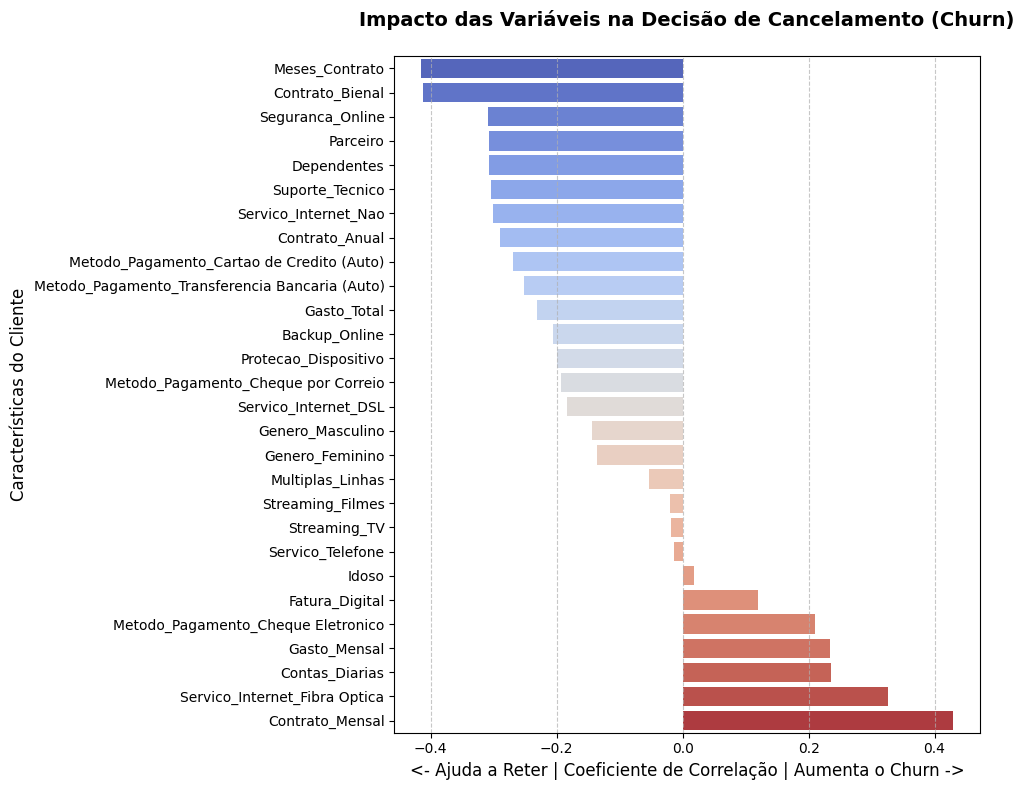

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ANALISANDO A CORRELAÇÃO COM O CHURN ---\n")

# juntando X e y temporariamente em um único DataFrame
df_para_correlacao = X_padronizado.copy()
df_para_correlacao['Churn'] = y_balanceado.values

# matriz de correlação completa
matriz_corr = df_para_correlacao.corr()
correlacao_churn = matriz_corr['Churn'].drop('Churn').sort_values()

# gráfico de barras
plt.figure(figsize=(10, 8))
sns.barplot(x=correlacao_churn.values, y=correlacao_churn.index, hue=correlacao_churn.index, palette='coolwarm', legend=False)


plt.title('Impacto das Variáveis na Decisão de Cancelamento (Churn)\n', fontsize=14, fontweight='bold')
plt.xlabel('<- Ajuda a Reter | Coeficiente de Correlação | Aumenta o Churn ->', fontsize=12)
plt.ylabel('Características do Cliente', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

No gráfico acima observa-se:

- As barras que crescem muito para a direita (vermelhas): são os fatores que mais empurram o cliente para fora da empresa (aumentam o Churn)

- As barras que crescem muito para a esquerda (azuis): são os fatores que mais seguram o cliente na empresa (diminuem o Churn)

--- ANÁLISE DIRECIONADA: COMPORTAMENTO ---



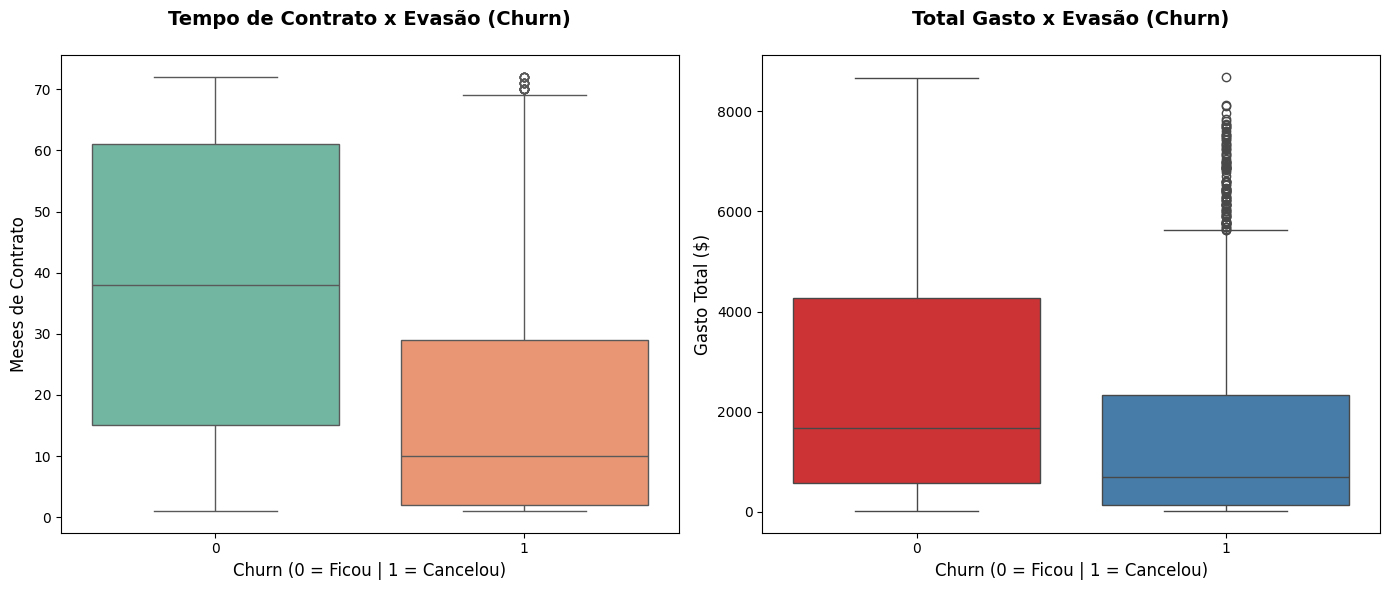

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ANÁLISE DIRECIONADA: COMPORTAMENTO ---\n")

plt.figure(figsize=(14, 6))

# gráfico 1 -> tempo de contrato x evasão
plt.subplot(1, 2, 1)

sns.boxplot(data=df, x='Churn', y='Meses_Contrato', hue='Churn', palette='Set2', legend=False)
plt.title('Tempo de Contrato x Evasão (Churn)\n', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0 = Ficou | 1 = Cancelou)', fontsize=12)
plt.ylabel('Meses de Contrato', fontsize=12)

# gráfico 2 -> total gasto x evasão
plt.subplot(1, 2, 2)

sns.boxplot(data=df, x='Churn', y='Gasto_Total', hue='Churn', palette='Set1', legend=False)
plt.title('Total Gasto x Evasão (Churn)\n', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0 = Ficou | 1 = Cancelou)', fontsize=12)
plt.ylabel('Gasto Total ($)', fontsize=12)

plt.tight_layout()
plt.show()

# 🤖 Modelagem Preditiva

In [41]:
from sklearn.model_selection import train_test_split

print("--- DIVIDINDO OS DADOS EM TREINO E TESTE ---\n")

# corte: 80% para treino e 20% para teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_padronizado,
    y_balanceado,
    test_size=0.20,
    random_state=42
)

print("Separação concluída!\n")

print(f"📚 Base de Treino (estudo): {X_treino.shape[0]} clientes")
print(f"\n📝 Base de Teste (prova final): {X_teste.shape[0]} clientes")

--- DIVIDINDO OS DADOS EM TREINO E TESTE ---

Separação concluída!

📚 Base de Treino (estudo): 8260 clientes

📝 Base de Teste (prova final): 2066 clientes


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1 -> regressão logística (requer padronização)
modelo_rl = LogisticRegression(max_iter=1000, random_state=42)
modelo_rl.fit(X_treino, y_treino)
previsoes_rl = modelo_rl.predict(X_teste)
print("1 -> Regressão Logística: Treinada com sucesso!")

# 2 -> random forest (não requer padronização)
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_treino, y_treino)
previsoes_rf = modelo_rf.predict(X_teste)
print("\n2 -> Random Forest: Treinado com sucesso!")

print("\nOs dois modelos prontos!")

1 -> Regressão Logística: Treinada com sucesso!

2 -> Random Forest: Treinado com sucesso!

Os dois modelos prontos!


--- AVALIAÇÃO DE DESEMPENHO DOS MODELOS ---

RESULTADOS: REGRESSÃO LOGÍSTICA
Acurácia no TREINO: 0.8516 (Para checar Overfitting/Underfitting)
Acurácia no TESTE:  0.8417
------------------------------
Precisão (Teste): 0.8416
Recall (Teste):   0.8307
F1-Score (Teste): 0.8361



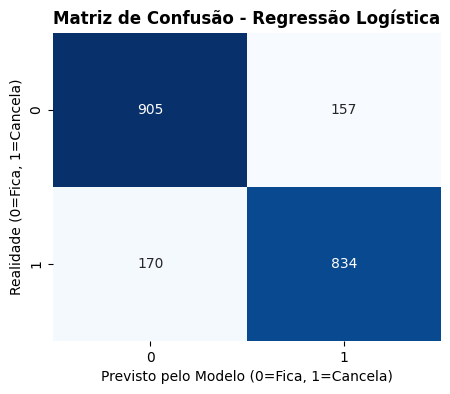




RESULTADOS: RANDOM FOREST
Acurácia no TREINO: 0.9983 (Para checar Overfitting/Underfitting)
Acurácia no TESTE:  0.8524
------------------------------
Precisão (Teste): 0.8464
Recall (Teste):   0.8506
F1-Score (Teste): 0.8485



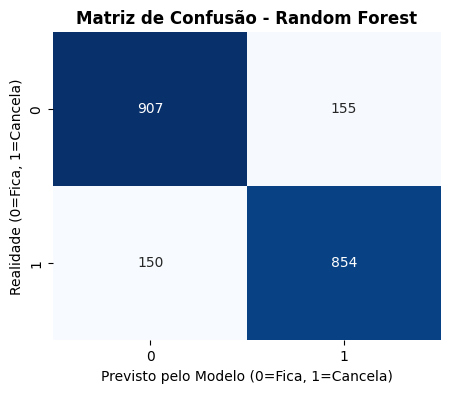

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- AVALIAÇÃO DE DESEMPENHO DOS MODELOS ---")

def avaliar_modelo(nome_modelo, modelo, X_treino, y_treino, X_teste, y_teste, previsoes_teste):
    # previsões no treino para checar overfitting
    previsoes_treino = modelo.predict(X_treino)
    acc_treino = accuracy_score(y_treino, previsoes_treino)

    # calculando métricas do Teste
    acc_teste = accuracy_score(y_teste, previsoes_teste)
    precisao = precision_score(y_teste, previsoes_teste)
    recall = recall_score(y_teste, previsoes_teste)
    f1 = f1_score(y_teste, previsoes_teste)

    print(f"\nRESULTADOS: {nome_modelo.upper()}")
    print(f"Acurácia no TREINO: {acc_treino:.4f} (Para checar Overfitting/Underfitting)")
    print(f"Acurácia no TESTE:  {acc_teste:.4f}")
    print("-" * 30)
    print(f"Precisão (Teste): {precisao:.4f}")
    print(f"Recall (Teste):   {recall:.4f}")
    print(f"F1-Score (Teste): {f1:.4f}\n")

    # matriz de confusão
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_teste, previsoes_teste)
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {nome_modelo}', fontweight='bold')
    plt.xlabel('Previsto pelo Modelo (0=Fica, 1=Cancela)')
    plt.ylabel('Realidade (0=Fica, 1=Cancela)')
    plt.show()

avaliar_modelo("Regressão Logística", modelo_rl, X_treino, y_treino, X_teste, y_teste, previsoes_rl)

print("\n")
avaliar_modelo("Random Forest", modelo_rf, X_treino, y_treino, X_teste, y_teste, previsoes_rf)

# 📋  Interpretação e Conclusões

--- ANÁLISE DE IMPORTÂNCIA DAS VARIÁVEIS ---



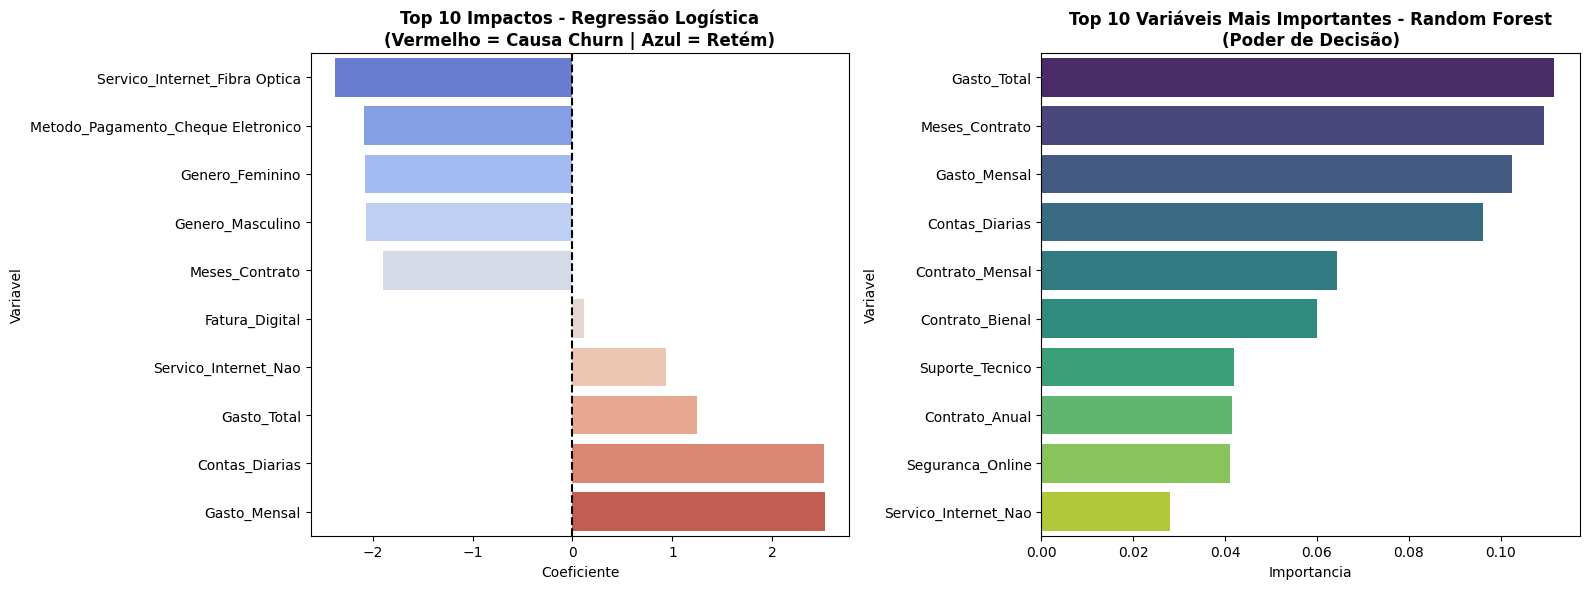

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ANÁLISE DE IMPORTÂNCIA DAS VARIÁVEIS ---\n")

features = X_treino.columns

# 1 -> importância na regressão logística
coeficientes_rl = modelo_rl.coef_[0]
df_importancia_rl = pd.DataFrame({'Variavel': features, 'Coeficiente': coeficientes_rl})

top_positivos_rl = df_importancia_rl.sort_values(by='Coeficiente', ascending=False).head(5)
top_negativos_rl = df_importancia_rl.sort_values(by='Coeficiente', ascending=True).head(5)
df_top_rl = pd.concat([top_positivos_rl, top_negativos_rl]).sort_values(by='Coeficiente')

# 2 -> importância no random forest
importancias_rf = modelo_rf.feature_importances_
df_importancia_rf = pd.DataFrame({'Variavel': features, 'Importancia': importancias_rf})

df_top_rf = df_importancia_rf.sort_values(by='Importancia', ascending=False).head(10)

#gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# gráfico 1 -> regressão logística
sns.barplot(ax=axes[0], data=df_top_rl, x='Coeficiente', y='Variavel', hue='Variavel', palette='coolwarm', legend=False)
axes[0].set_title('Top 10 Impactos - Regressão Logística\n(Vermelho = Causa Churn | Azul = Retém)', fontweight='bold')
axes[0].axvline(0, color='black', linestyle='--') # Linha do zero

# gráfico 2 -> random forest
sns.barplot(ax=axes[1], data=df_top_rf, x='Importancia', y='Variavel', hue='Variavel', palette='viridis', legend=False)
axes[1].set_title('Top 10 Variáveis Mais Importantes - Random Forest\n(Poder de Decisão)', fontweight='bold')

plt.tight_layout()
plt.show()

# 📊 Relatório Final: Previsão e Mitigação de Evasão de Clientes (Churn)

**1. Introdução**

Este projeto tem como objetivo identificar os principais fatores que motivam o cancelamento de serviços (Churn) e desenvolver modelos preditivos capazes de antecipar essas evasões, permitindo ações proativas de retenção e proteção de receita.

**2. Metodologia e Modelagem**

Os dados passaram por tratamento, balanceamento (SMOTE) e duas abordagens de modelagem foram implementadas para comparação:

- **Modelo 1: Regressão Logística**

  - Justificativa: ddotado por sua alta interpretabilidade e velocidade.

  - Pré-requisito (Padronização): foi estritamente necessária. Como este modelo calcula distâncias matemáticas, variáveis de grande magnitude (ex: Gasto Total) ofuscariam variáveis menores (ex: Meses). A padronização colocou todos os dados na mesma escala de importância.

- **Modelo 2: Random Forest (Floresta Aleatória)**

  - Justificativa: adotado por sua alta capacidade de lidar com dados complexos e padrões não-lineares.

  - Pré-requisito: modelos baseados em árvores decidem através de cortes lógicos (ex: contrato > 12 meses?). Portanto, não exigem padronização, sendo imunes à diferença de escala entre as variáveis.

**3. Avaliação de Desempenho e Análise Crítica**

- Modelo Vencedor: o Random Forest obteve o melhor resultado com um Recall de 85.06%. No contexto de Churn, maximizar o Recall é crucial para garantir que o menor número possível de clientes em risco passe despercebido.

- Análise de Overfitting/Underfitting: a Regressão Logística manteve estabilidade (acurácia de ~85% tanto em treino quanto em teste). O Random Forest, no entanto, apresentou Overfitting (acurácia treino: 99.8% vs teste: 85.2%), indicando memorização excessiva dos dados.

  - dica para futuros ajustes: para próximas iterações, recomenda-se aplicar técnicas de poda (reduzir a profundidade máxima das árvores) para melhorar a generalização do modelo.

**4. Principais Fatores de Risco (Motivadores de Churn)**

A análise de importância das variáveis extraída dos algoritmos revelou três pilares críticos de evasão:

1. **Baixa Fidelidade:** o Contrato_Mensal é o maior gatilho isolado de cancelamentos

2. **Ciclo de Vida Inicial:** clientes com pouco tempo de base (Meses_Contrato) cruzado com faturas altas apresentam risco imediato

3. **Atrito em Produtos Específicos:** o serviço de Fibra Óptica concentra uma taxa de evasão desproporcional em relação aos demais produtos

**5. Recomendações Estratégicas (Planos de Ação)**

Com base nas previsões realizadas, é sugerido 4 ações imediatas para o negócio:

- Campanhas de Upsell para Fidelização: oferecer incentivos agressivos (descontos escalonados ou upgrades de serviço) para converter clientes de Contratos Mensais em anuais/bienais.

- Onboarding Proativo: implementar contato direcionado pela equipe de Customer Success nos primeiros 90 dias, período identificado como de altíssima vulnerabilidade.

- Auditoria Operacional: revisar imediatamente a infraestrutura técnica e o posicionamento de preço da Fibra Óptica, devido ao alto volume de cancelamentos associados ao serviço.

- Atuação Preditiva (Retenção Antecipada): integrar as predições do Random Forest ao CRM (Gestão de Relacionamento com o Cliente) da empresa, gerando listas diárias de "Clientes em Risco" para que a equipe de retenção atue antes da solicitação de cancelamento.